## Step 0: Imports and Setup

This step imports all necessary libraries for data processing, modeling, evaluation, and visualisation. These libraries include tools for collaborative filtering (Surprise), text vectorization (TF-IDF), machine learning models (LightGBM, XGBoost), and general utilities (NumPy, Pandas, tqdm). This setup is required before any data operation begins.

In [2]:
!pip install scikit-surprise

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from tqdm.notebook import tqdm
from collections import defaultdict

# Text Vectorization and Similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Data Preprocessing and Evaluation
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Dimensionality Reduction
from sklearn.decomposition import TruncatedSVD

# ML Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb

# Surprise Library for Collaborative Filtering
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split as surprise_split, cross_validate, GridSearchCV


### Path setup (Kaggle vs local)

The next cell sets `TRAIN_PATH` and `TEST_PATH` so the notebook works on **Kaggle** (competition data) and **locally** (place `train.csv` and `test.csv` in the project folder, or set `DATA_DIR` to e.g. `"data"`).

In [ ]:
# Path setup: works on Kaggle and locally (place train.csv & test.csv in this folder or set DATA_DIR)
import os
if os.path.exists("/kaggle/input"):
    DATA_DIR = "/kaggle/input/ssd-assignment"
else:
    DATA_DIR = "."  # current directory; or use "data" if your CSVs are in a data/ folder
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
print(f"Data directory: {DATA_DIR}")
print(f"Train: {TRAIN_PATH}, Test: {TEST_PATH}")

## Step 1a: Data Loading and Overview

n this step, we load the training and test datasets using pandas. These CSV files contain user-product interactions and metadata required for our recommender system. Previewing the data helps verify the format and gives a quick glimpse of features such as user_id, product_id, rating, and product_name. This understanding is crucial for downstream modeling and feature engineering.

In [5]:
# Load train and test data (paths set in path-setup cell above)
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

# Preview
print("Train Sample:\n", df_train.head(), "\n")
print("Test Sample:\n", df_test.head())

Train Sample:
    user_id  product_id                              product_name  rating  \
0     1813      154533                           Beautiful Thing       5   
1     1944      192838                             Almost Famous       5   
2      534      202590                        A Clockwork Orange       5   
3     1811      140456  Great Expectations (Wordsworth Classics)       4   
4      102      154278                                Phenomenon       5   

   votes  helpful_votes  ID  
0     10              8   0  
1      4              2   1  
2      5              5   2  
3      1              0   3  
4      0              0   4   

Test Sample:
    ID  user_id  product_id                                       product_name
0   0     1916      185507                                  Maria [Australia]
1   1     1759      143430  The Mitchells: Five for Victory (Van Stockum, ...
2   2     1980      155861                     Superman Cartoons of Max & Dav
3   3     1502      

## Step 1b: Data Integrity Checks

Before modeling, it is essential to check for missing values and duplicated entries. Missing values can affect model accuracy or even break training code. Duplicate interactions (same user-product pairs) may introduce bias or noise, so identifying them helps us decide whether to drop or keep them.

In [27]:
# Check for missing values
print("Missing values in train:\n", df_train.isnull().sum())
print("Missing values in test:\n", df_test.isnull().sum())

# Check for duplicates (optional)
duplicates = df_train.duplicated(subset=['user_id', 'product_id'])
print(f"Number of duplicates: {duplicates.sum()}")

# How many unique users and products
print(f"Unique users: {df_train['user_id'].nunique()}")
print(f"Unique products: {df_train['product_id'].nunique()}")

Missing values in train:
 user_id          0
product_id       0
product_name     0
rating           0
votes            0
helpful_votes    0
ID               0
dtype: int64
Missing values in test:
 ID              0
user_id         0
product_id      0
product_name    0
dtype: int64
Number of duplicates: 0
Unique users: 2000
Unique products: 201325


## Step 2: Exploratory Data Analysis (EDA)

### 2a. Rating Distribution
Understanding how ratings are distributed helps identify potential bias or imbalance in user feedback. If the data is skewed towards high ratings, models may learn to overpredict. Here, we plot the frequency of each rating score from 1 to 5.

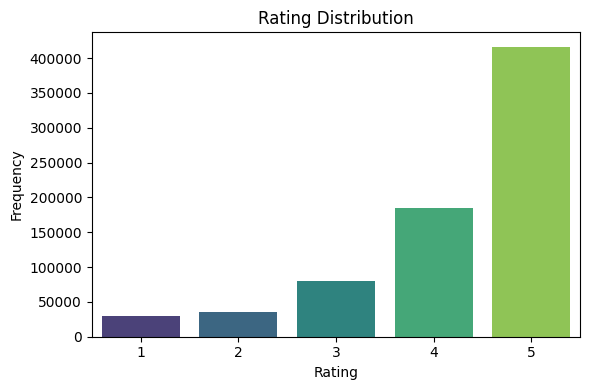

In [28]:
# Plot rating distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x='rating', palette='viridis')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### 2b. Most Rated Products

Some products receive far more ratings than others. These "popular" products may dominate model learning or be suitable for collaborative filtering methods like matrix factorization. We identify the top 10 most frequently rated products.

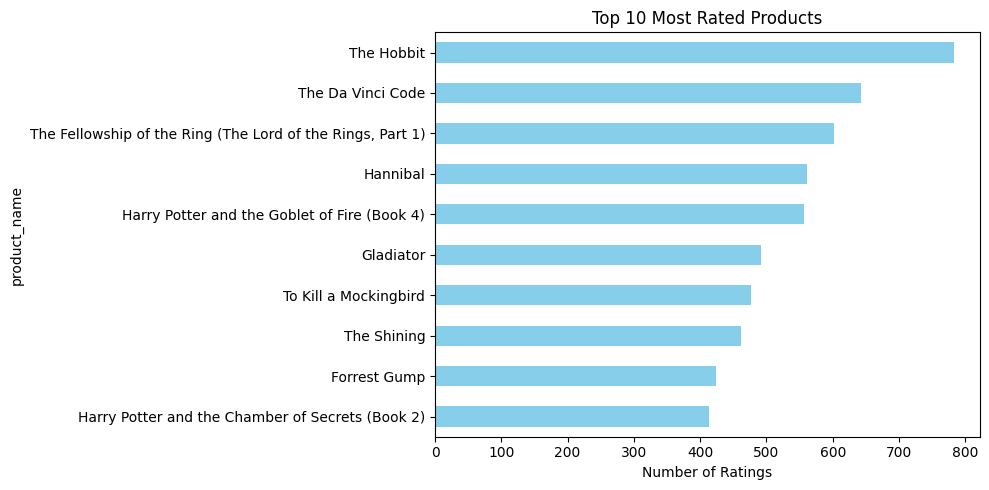

In [29]:
# Top 10 most rated product names
popular_products = df_train['product_name'].value_counts().head(10)

plt.figure(figsize=(10, 5))
popular_products.sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Rated Products')
plt.xlabel('Number of Ratings')
plt.tight_layout()
plt.show()


### 2c. User Rating Activity

Recommender systems rely on user history. Users with too few ratings may not have sufficient data to learn preferences (cold-start problem), while very active users could skew the model. We plot the number of ratings per user, focusing on users with ≤100 ratings.

User Rating Stats:
Min: 4
Max: 112483
Mean: 372.94
Median: 219.0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


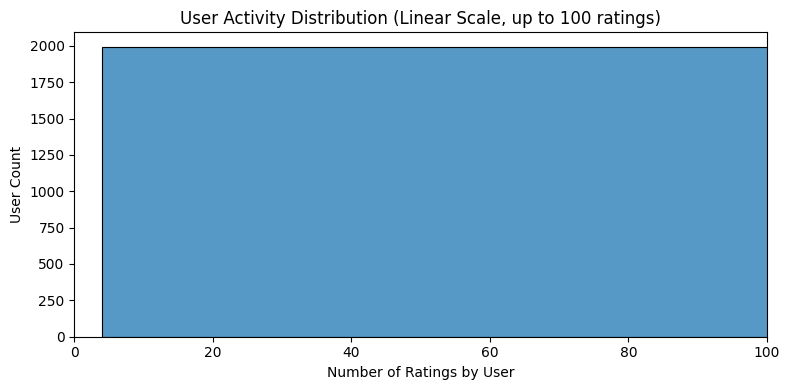

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


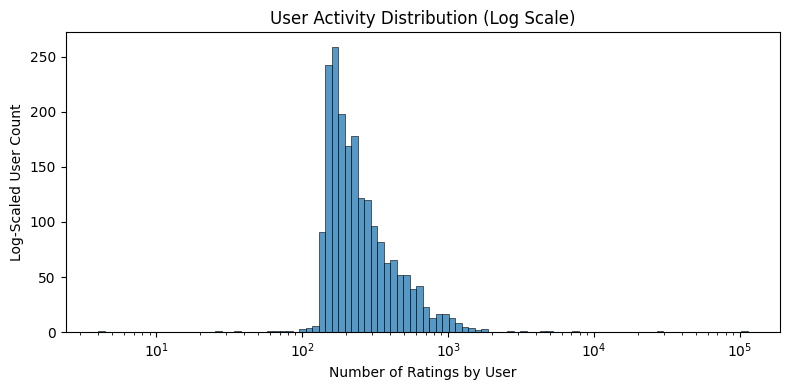

In [30]:
# Summary stats
user_counts = df_train['user_id'].value_counts()
print("User Rating Stats:")
print(f"Min: {user_counts.min()}")
print(f"Max: {user_counts.max()}")
print(f"Mean: {user_counts.mean():.2f}")
print(f"Median: {user_counts.median()}")

# Linear scale
plt.figure(figsize=(8, 4))
sns.histplot(user_counts, bins=50, kde=False)
plt.xlim(0, 100)
plt.title('User Activity Distribution (Linear Scale, up to 100 ratings)')
plt.xlabel('Number of Ratings by User')
plt.ylabel('User Count')
plt.tight_layout()
plt.show()

# Log scale
plt.figure(figsize=(8, 4))
sns.histplot(user_counts, bins=100, log_scale=True)
plt.title('User Activity Distribution (Log Scale)')
plt.xlabel('Number of Ratings by User')
plt.ylabel('Log-Scaled User Count')
plt.tight_layout()
plt.show()


### 2d. Product Appearance in Train vs Test

To simulate real-world recommendations, we must assess how many products in the test set were already seen during training. Products unseen in training pose a cold-start challenge. We tag each training entry based on whether its product also appears in the test set.

In [31]:
# Clean product names
def clean_product_name(name):
    if pd.isna(name) or name == '':
        return ''
    name = str(name).lower()
    name = re.sub(r'[^\w\s]', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name

df_train['clean_product_name'] = df_train['product_name'].apply(clean_product_name)

# Rating statistics
global_mean = df_train['rating'].mean()
print(f"Global mean rating: {global_mean:.3f}")

# Product stats
product_name_stats = df_train.groupby('clean_product_name')['rating'].agg(['mean', 'std', 'count'])
popular_products = product_name_stats[product_name_stats['count'] >= 3]
rare_products = product_name_stats[(product_name_stats['count'] < 3) & (product_name_stats['count'] >= 1)]

print(f"Popular products (>=3 ratings): {len(popular_products)}")
print(f"Rare products (1-2 ratings): {len(rare_products)}")


Global mean rating: 4.239
Popular products (>=3 ratings): 50497
Rare products (1-2 ratings): 124395


### Step 2f: User-Level Stats and Train-Validation Splits
Markdown Explanation:

We generate statistics on user activity, including the number of ratings per user. This helps identify highly active users or potential cold-start users. We also split the training set into train/validation using a user-based split to ensure user-specific patterns are preserved.

In [32]:
# User stats
user_stats = df_train.groupby('user_id')['rating'].agg(['mean', 'std', 'count'])
print(f"Total unique users: {len(user_stats)}")

# Train-validation split (user-based)
from sklearn.model_selection import train_test_split
unique_users = df_train['user_id'].unique()
train_users, val_users = train_test_split(unique_users, test_size=0.2, random_state=42)

train_split = df_train[df_train['user_id'].isin(train_users)].reset_index(drop=True)
val_split = df_train[df_train['user_id'].isin(val_users)].reset_index(drop=True)

print(f"Train Ratings: {len(train_split)}")
print(f"Validation Ratings: {len(val_split)}")

# View a sample
val_split[['user_id', 'product_name', 'rating']].head(10)


Total unique users: 2000
Train Ratings: 614486
Validation Ratings: 131403


,user_id,product_name,rating
0,356,My Own Prison,4
1,1102,The Bluest Eye,4
2,1851,The Fifth Element (Superbit Collection),4
3,123,Little Women (Story Theatre for Young Readers),5
4,486,One Hundred Years of Solitude,5
5,982,Death Rides A Horse,3
6,834,Robert Kennedy : His Life,5
7,982,The Fog (Special Edition),5
8,1316,Forrest Gump,5
9,319,Trekkies,4


## Step 3: Memory-Efficient Recommender System – First Iteration

This model is designed to provide accurate rating predictions using minimal memory overhead. It avoids large user-item interaction matrices by combining three key strategies:

Collaborative filtering using SVD, but only on frequently rated products

Statistical estimation based on user and product biases

Content-based filtering using TF-IDF and cosine similarity, computed on demand

This hybrid method ensures scalability and generalization, especially for new or sparsely rated products. The first iteration focuses on establishing a robust baseline for clean and memory-conscious recommendations.

#### Function: `clean_product_name`

This function cleans the product names to ensure consistency in the dataset. It performs the following:
- Converts text to lowercase
- Removes all punctuation
- Replaces multiple spaces with a single space
- Strips leading/trailing whitespace

This preprocessing step is critical because inconsistent product names (e.g., different casing or punctuation) can lead to duplicate or fragmented entries, reducing model accuracy.


In [33]:
def clean_product_name(name):
    """
    Lowercase, remove punctuation, normalize spaces.
    """
    if pd.isna(name) or name == '':
        return ''
    name = str(name).lower()
    name = re.sub(r'[^\w\s]', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()
    return name


#### Class Initialization: prepare_training_data

This block sets up the core structure of the recommender system. It initializes:

Hyperparameters: similarity_threshold, max_tfidf_features

Collaborative filtering components: svd_model, user_encoder, name_encoder

Content-based filtering components: tfidf_vectorizer, tfidf_matrix, unique_names_list

Statistics: global_mean, product_name_stats, user_stats

Product tracking: train_product_names

These will be populated during training and used for efficient hybrid predictions.

In [34]:
def prepare_training_data(df):
    df_clean = df.copy()
    df_clean['clean_product_name'] = df_clean['product_name'].apply(clean_product_name)
    df_clean = df_clean[df_clean['clean_product_name']!=''].reset_index(drop=True)
    
    global_mean = df_clean['rating'].mean()
    prod_stats   = df_clean.groupby('clean_product_name')['rating']\
                          .agg(['mean','std','count']).to_dict('index')
    user_stats   = df_clean.groupby('user_id')['rating']\
                          .agg(['mean','std','count']).to_dict('index')
    train_names  = set(df_clean['clean_product_name'])
    counts       = df_clean['clean_product_name'].value_counts()
    popular_names= counts[counts>=3].index.tolist()
    unique_names = df_clean['clean_product_name'].unique()
    
    return df_clean, global_mean, prod_stats, user_stats, train_names, popular_names, unique_names


#### Training Collaborative Filtering Model: _train_svd() Function

This internal method trains a compact SVD (Singular Value Decomposition) model:

Filters the training data to include only products with at least 3 ratings (popular_names)

Encodes users and product names to integer indices

Prepares the dataset in Surprise's expected format

Trains the SVD model using moderate settings (30 latent factors, regularization, and limited epochs)

This SVD model is then used for rating prediction when both user and product are known and reliable

In [35]:
def train_svd(df_clean, popular_names):
    """
    Trains an SVD model on products with ≥3 ratings.
    Returns (svd_model, user_encoder, name_encoder).
    """
    svd_df = df_clean[df_clean['clean_product_name'].isin(popular_names)].copy()
    if svd_df.empty:
        return None, {}, {}
    
    users = svd_df['user_id'].unique()
    names = svd_df['clean_product_name'].unique()
    u_enc = {u:i for i,u in enumerate(users)}
    n_enc = {n:i for i,n in enumerate(names)}
    
    svd_df['user_idx'] = svd_df['user_id'].map(u_enc)
    svd_df['name_idx'] = svd_df['clean_product_name'].map(n_enc)
    
    reader  = Reader(rating_scale=(1,5))
    data    = Dataset.load_from_df(svd_df[['user_idx','name_idx','rating']], reader)
    trainset= data.build_full_trainset()
    svd     = SVD(n_factors=30, reg_all=0.05, lr_all=0.005, n_epochs=15, random_state=42)
    svd.fit(trainset)
    return svd, u_enc, n_enc


#### Building Lightweight Content-Based Similarity: _build_similarity()

This internal method constructs a memory-efficient content-based similarity system:

Uses TF-IDF vectorization to represent cleaned product names as text features.

Applies bigrams (ngram_range=(1, 2)) and filters terms using min_df=3 and max_df=0.7 to avoid rare and overly common tokens.

Restricts the number of TF-IDF features (max_features) to reduce memory footprint.

Stores the resulting TF-IDF matrix and corresponding list of product names for on-demand similarity computation.

This allows the model to find similar products even for previously unseen items without building a full similarity matrix.

In [36]:
def build_tfidf_similarity(unique_names, max_features=500):
    """
    Fits TF-IDF on product names; returns (vectorizer, matrix, list_of_names).
    """
    vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.7,
                          max_features=max_features, stop_words='english')
    mat = vec.fit_transform(unique_names)
    return vec, mat, list(unique_names)


#### Rating Prediction Logic: predict_rating()
This public method determines how a rating should be predicted for a given user_id and product_name. It selects from three strategies:

SVD-based prediction if both user and product are known.

Statistical prediction if product is known but not encoded.

Content-similarity-based prediction for new/unknown products.

#### Strategy 1 – SVD-Based Prediction: _predict_with_svd()
If the user and product are both known and were included during SVD training:

Predicts the rating using the trained SVD model.

If either index is missing or an error occurs, falls back to statistical estimation.

#### Strategy 2 – Statistical Prediction: _predict_with_stats()
When collaborative filtering fails, this strategy uses:

Global mean as base.

User bias (user's average rating vs global mean) scaled by 0.6.

Product bias (product's average rating vs global mean) scaled by 0.4.

Clamps prediction to the [1.0, 5.0] rating range.

#### Strategy 3 – Content-Similarity Prediction: _predict_with_similarity()
For new or unknown products:

Identifies similar products using TF-IDF cosine similarity.

Computes a weighted average of similar products' ratings.

Blends it with the user's historical mean (70% content-based, 30% user-based).

Falls back to statistical method if no similar products are found.

On-Demand Similar Product Finder: _find_similar_products()
Transforms a product name into a TF-IDF vector.

Computes cosine similarity against the training TF-IDF matrix.

Returns the top k similar products above a similarity threshold.

If TF-IDF fails or isn't initialized, returns an empty list.

In [37]:
def predict_rating(u, p, global_mean, prod_stats, user_stats,
                   svd, u_enc, n_enc, tfidf_vec, tfidf_mat, names_list, train_names, thresh=0.3):
    clean = clean_product_name(p)
    if not clean:
        return global_mean
    
    # 1) SVD
    if clean in train_names and clean in n_enc and svd:
        ui, ni = u_enc.get(u), n_enc.get(clean)
        if ui is not None and ni is not None:
            est = svd.predict(ui, ni).est
            return np.clip(est,1,5)
    
    # 2) Stats
    if clean in train_names:
        pred = global_mean
        if u in user_stats:
            pred += 0.6*(user_stats[u]['mean']-global_mean)
        if clean in prod_stats:
            pred += 0.4*(prod_stats[clean]['mean']-global_mean)
        return np.clip(pred,1,5)
    
    # 3) Similarity
    vec = tfidf_vec.transform([clean])
    sims= cosine_similarity(vec, tfidf_mat).flatten()
    idxs= sims.argsort()[-5:][::-1]
    pairs=[(names_list[i],sims[i]) for i in idxs if sims[i]>=thresh]
    if not pairs:
        return global_mean
    ratings, weights = [], []
    for name,sim in pairs:
        if name in prod_stats:
            ratings.append(prod_stats[name]['mean'])
            weights.append(sim)
    if not ratings:
        return global_mean
    wavg = np.dot(ratings,weights)/np.sum(weights)
    u_mean = user_stats.get(u,{}).get('mean', global_mean)
    return np.clip(0.7*wavg + 0.3*u_mean,1,5)


#### Batch Prediction: predict_batch()

This method performs bulk prediction over a test dataset:

Accepts a DataFrame (df_test) containing user_id and product_name columns.

Uses predict_rating() internally to generate predictions row by row.

Outputs a NumPy array of predicted ratings, maintaining order with the input DataFrame.

Includes a print statement summarizing the number of test records being processed.

This function ensures efficient scoring over the test set for evaluation or submission.

In [38]:
def predict_batch(df, *parts):
    return np.array([
        predict_rating(r.user_id, r.product_name, *parts)
        for r in df.itertuples()
    ])


#### Model Validation: validate_model()

This function evaluates the performance of the MemoryEfficientRecommender model using a user-based train/validation split.

Splitting: Randomly selects 80% of users for training and the remaining 20% for validation. This ensures that the model is tested on unseen users to assess generalization.

Training: Trains the recommender on the train_data subset using the fit() method.

Prediction: Generates predictions for the val_data using the predict_batch() method.

Evaluation:

RMSE (Root Mean Squared Error): Measures the average squared prediction error.

R² Score: Indicates how well the predictions approximate the actual ratings.

MAE (Mean Absolute Error): Captures average absolute prediction error.

Output: Prints all three metrics and returns the trained model instance for further use.

In [39]:
def validate(df_train):
    df_c, gm, ps, us, tn, pop, unames = prepare_training_data(df_train)
    svd, u_enc, n_enc = train_svd(df_c, pop)
    tv, tm, nl = build_tfidf_similarity(unames)
    
    parts = (gm, ps, us, svd, u_enc, n_enc, tv, tm, nl, tn)
    # split users
    us_all = df_c['user_id'].unique()
    tr_u, va_u = train_test_split(us_all, test_size=0.2, random_state=42)
    tr_df = df_c[df_c['user_id'].isin(tr_u)]
    va_df = df_c[df_c['user_id'].isin(va_u)]
    
    preds = predict_batch(va_df, *parts)
    actual= va_df['rating'].values
    preds = np.nan_to_num(preds, nan=gm)
    
    print("Validation Results")
    print(" RMSE:",      np.sqrt(mean_squared_error(actual,preds)))
    print(" R2:",        r2_score(actual,preds))
    print(" MAE:",       np.mean(abs(actual-preds)))
    return parts


#### Generate Test Predictions and Submission File

This function is used to create a CSV file with model predictions formatted for submission.

Input: Takes a trained model and the test dataset df_test.

Prediction: Uses predict_batch() to generate ratings for all user-product pairs in the test set.

Output Format:

Creates a DataFrame with two columns:

ID: Taken directly from the test dataset.

rating: Model-generated predicted rating.

Saving: The predictions are saved as efficient_submission.csv in the current working directory, ready for evaluation or submission.

In [40]:
def make_submission(df_test, parts, out_file="submission.csv"):
    preds = predict_batch(df_test, *parts)
    df_test['rating']= preds
    df_test[['ID','rating']].to_csv(out_file,index=False)
    print("Saved:", out_file)

#### Model Training, Validation, and Submission Generation

We now train and validate our hybrid recommender system using the cleaned training data. Once validated, we generate predictions on the test set and export the final submission file.

In [41]:
# 10.2 Validate & get model parts
model_parts = validate(df_train)

# 10.3 Generate final submission
make_submission(df_test, model_parts, out_file="efficient_submission.csv")

Validation Results
 RMSE: 0.7285991640942143
 R2: 0.49426984992743217
 MAE: 0.5294821483787655
Saved: efficient_submission.csv


## Hybrid Recommender

This notebook presents a Hybrid Recommender System that combines:

Matrix Factorization (SVD) — great when we have lots of user–item interactions.

Content-Based Fallbacks (TF–IDF, Bias-based predictions) — helpful for newer or rarely-rated items.

The idea is simple: use SVD when we have enough data, and fall back to smarter statistical or content-based methods when we don’t.

### Data Cleaning: clean_product_name(name)

We want product names to be comparable:

Convert to lowercase.

Remove years (like 1999, 2020), symbols, and fluff like "Special Edition".

Keep dates or numeric codes as-is if they look important (e.g., “123-456”).

This helps avoid duplicate entries like:


* Avengers (Deluxe Edition)
* avengers


becoming two separate items.

In [6]:
def clean_product_name(name):
    """Enhanced cleaning that preserves pure number names"""
    if pd.isna(name) or name == '':
        return ''
    
    name = str(name).lower()
    
    # Check if it's purely numbers/dates - if so, keep as-is
    if re.match(r'^[\d\-\/\s]+$', name):
        return name.strip()
    
    # Apply normal cleaning for text names
    edition_patterns = [
        r'\(special edition\)', r'\(director\'s cut\)', r'\(extended edition\)',
        r'\(widescreen edition\)', r'\(fullscreen edition\)', r'\(remastered\)',
        r'\(unrated\)', r'\(soundtrack\)', r'\(dvd\)', r'\(blu ray\)',
        r'\(collectors edition\)', r'\(anniversary edition\)', r'\(ultimate edition\)',
        r'\(original motion picture soundtrack\)', r'\(deluxe edition\)'
    ]
    
    for pattern in edition_patterns:
        name = re.sub(pattern, '', name)
    
    # Remove years but keep important numbers (like sequels)
    name = re.sub(r'\b(19|20)\d{2}\b', '', name)
    
    # Clean and normalize
    name = re.sub(r'[^\w\s]', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name

### Confidence Score: calculate_original_confidence(count)
A simple formula to measure how "trustworthy" a product’s average rating is: confidence = min(1.0, count / 5)

So:

5 or more ratings = full confidence (1.0)

Fewer than 5 = reduced confidence

This helps us trust items with more data and reduce the influence of those with only 1–2 ratings.

### Quality Score: calculate_selective_quality_scores(df_train)

We compute extra adjustment scores for products with lots of:

Ratings

Votes

Helpful votes

Only products that are well-reviewed and consistent get a small boost (or drop). We use a formula combining rating consistency and helpfulness.

Why? To slightly tweak predictions for crowd-approved products — not everything deserves a boost.

In [8]:
def calculate_original_confidence(count, confidence_divisor):
    """Original confidence calculation that worked well"""
    return min(1.0, count / confidence_divisor)

def calculate_selective_quality_scores(df_train, quality_confidence_threshold):
    """Selective quality scoring - only for high-confidence products"""
    print("Calculating selective quality scores...")
    
    quality_stats = df_train.groupby('clean_product_name').agg({
        'votes': ['sum', 'mean', 'std'],
        'helpful_votes': ['sum', 'mean'],
        'rating': ['count', 'std']
    }).fillna(0)
    
    quality_stats.columns = ['_'.join(col).strip() for col in quality_stats.columns]
    
    product_quality_scores = {}
    
    for product_name in quality_stats.index:
        total_votes = quality_stats.loc[product_name, 'votes_sum']
        total_helpful = quality_stats.loc[product_name, 'helpful_votes_sum']
        rating_count = quality_stats.loc[product_name, 'rating_count']
        rating_std = quality_stats.loc[product_name, 'rating_std']
        
        # Only calculate for products with sufficient data
        if rating_count >= 10 and total_votes >= 5:  # High confidence threshold
            helpfulness_ratio = (total_helpful + 1) / (total_votes + 2)
            count_confidence = min(1.0, rating_count / 10)
            consistency_bonus = max(0, 1 - rating_std) if rating_std > 0 else 0.5
            
            overall_confidence = 0.7 * count_confidence + 0.3 * consistency_bonus
            
            # Only store if confidence is high enough
            if overall_confidence >= quality_confidence_threshold:
                product_quality_scores[product_name] = {
                    'helpfulness_ratio': helpfulness_ratio,
                    'confidence': overall_confidence,
                    'total_votes': total_votes,
                    'rating_count': rating_count
                }
    
    return product_quality_scores

### Statistics Calculation

This step prepares all the key statistics needed for prediction:

Global Mean: Used as a fallback when we don't have enough info about a user or product.

Product Stats: For each product, we calculate the mean rating, standard deviation, count, and a confidence score (based on how many ratings it has). This helps us trust popular products more.

User Stats: Same as product stats but for users — lets us understand individual user preferences and reliability.

Product-to-User Mapping: Builds a mapping of which users rated each product. Useful later for similarity-based lookups and cold-start handling.

In [9]:
# ========================================
# CELL 3: Statistics Calculation
# ========================================

def calculate_statistics(df_train, confidence_divisor):
    """Calculate user and product statistics with optimized performance"""
    global_mean = df_train['rating'].mean()
    
    # Product statistics with original confidence (OPTIMIZED)
    print("Calculating product statistics (optimized)...")
    start_time = time.time()
    
    product_stats = df_train.groupby('clean_product_name')['rating'].agg([
        'mean', 'std', 'count', 'min', 'max'
    ])
    
    print(f"Computing confidence for {len(product_stats):,} products...")
    # Vectorized confidence calculation - much faster
    product_stats['confidence'] = product_stats['count'].apply(
        lambda c: calculate_original_confidence(c, confidence_divisor)
    )
    
    # Convert to dictionary efficiently
    product_name_stats = {
        product_name: {
            'mean': row['mean'],
            'std': row['std'], 
            'count': row['count'],
            'confidence': row['confidence']
        }
        for product_name, row in product_stats.iterrows()
    }
    
    elapsed_time = time.time() - start_time
    print(f"Product statistics completed in {elapsed_time:.1f} seconds!")
    
    # User statistics with original confidence (OPTIMIZED)
    print("Calculating user statistics (optimized)...")
    start_time = time.time()
    
    user_stats = df_train.groupby('user_id')['rating'].agg([
        'mean', 'std', 'count', 'min', 'max'
    ])
    
    print(f"Computing confidence for {len(user_stats):,} users...")
    # Vectorized confidence calculation - much faster
    user_stats['confidence'] = user_stats['count'].apply(
        lambda c: calculate_original_confidence(c, confidence_divisor)
    )
    
    # Convert to dictionary efficiently
    user_stats_dict = {
        user_id: {
            'mean': row['mean'],
            'std': row['std'],
            'count': row['count'], 
            'confidence': row['confidence']
        }
        for user_id, row in user_stats.iterrows()
    }
    
    elapsed_time = time.time() - start_time
    print(f"User statistics completed in {elapsed_time:.1f} seconds!")
    
    # Build product-to-users mapping (optimized)
    print("Building product-to-users mapping (optimized approach)...")
    start_time = time.time()
    
    grouped = df_train.groupby('clean_product_name')['user_id'].apply(lambda x: x.unique()).to_dict()
    product_to_users = grouped
    
    elapsed_time = time.time() - start_time
    print(f"User mapping completed in {elapsed_time:.1f} seconds!")
    print(f"Mapped {len(product_to_users):,} products to their users")
    
    return global_mean, product_name_stats, user_stats_dict, product_to_users

### SVD Training

We train an Enhanced SVD model on popular products that have enough ratings.

What this does:


* Filters the training data to include only products with sufficient ratings (i.e., "popular").
* Encodes users and product names as numeric indices.Prepares the data using the surprise library format.
* Trains the SVD model using improved hyperparameters:

More latent factors (e.g., 85)

Lower regularization

Higher learning rate

More training epochs

This gives better predictions for well-known user–product pairs.

In [10]:
# ========================================
# CELL 4: SVD Training
# ========================================

def train_enhanced_svd(df_train, popular_names, n_svd_factors, svd_reg, svd_lr, svd_epochs):
    """Train enhanced SVD with better hyperparameters"""
    print("Training Enhanced SVD...")
    
    svd_data = df_train[df_train['clean_product_name'].isin(popular_names)].copy()
    
    if len(svd_data) == 0:
        print("Warning: No popular products for SVD")
        return None, {}, {}
    
    print(f"SVD data: {len(svd_data):,} ratings")
    
    # Create encoders
    print("Creating user and product encoders...")
    unique_users = svd_data['user_id'].unique()
    unique_names = svd_data['clean_product_name'].unique()
    
    print(f"Encoding {len(unique_users):,} users and {len(unique_names):,} products...")
    user_encoder = {user: idx for idx, user in enumerate(unique_users)}
    name_encoder = {name: idx for idx, name in enumerate(unique_names)}
    
    # Prepare SVD data
    print("Preparing SVD data...")
    svd_data['user_idx'] = svd_data['user_id'].map(user_encoder)
    svd_data['name_idx'] = svd_data['clean_product_name'].map(name_encoder)
    
    # Train enhanced SVD
    print(f"Starting Enhanced SVD training with {svd_epochs} epochs...")
    print("This may take several minutes...")
    reader = Reader(rating_scale=(1, 5))
    data = Dataset.load_from_df(svd_data[['user_idx', 'name_idx', 'rating']], reader)
    trainset = data.build_full_trainset()
    
    svd_model = SVD(
        n_factors=n_svd_factors,  # Enhanced: 85 factors
        reg_all=svd_reg,          # Enhanced: 0.01 regularization
        lr_all=svd_lr,            # Enhanced: 0.01 learning rate
        n_epochs=svd_epochs,      # Enhanced: 40 epochs
        random_state=42,
        verbose=True
    )
    
    svd_model.fit(trainset)
    print(f"Enhanced SVD training completed: {len(unique_users):,} users x {len(unique_names):,} products")
    
    return svd_model, user_encoder, name_encoder


### TF-IDF Similarity System

We build a TF-IDF vectorizer to measure how similar product names are based on their text.

Why this matters:

Helps us find similar items for cold-start or rarely rated products.

Uses 1–4 word n-grams, removes stopwords, and limits to the top features (max_features).

Generates a sparse matrix representing product name vectors — used later to compute cosine similarity on the fly.

This is used in the hybrid model’s fallback logic (Case 2 & Case 3).

In [11]:
# ========================================
# CELL 5: TF-IDF Similarity System
# ========================================

def build_enhanced_similarity(unique_names, max_tfidf_features):
    """Build enhanced similarity system"""
    print("Building enhanced similarity system...")
    print(f"Processing {len(unique_names):,} unique product names...")
    
    print("Setting up TF-IDF vectorizer...")
    tfidf_vectorizer = TfidfVectorizer(
        ngram_range=(1, 4),
        min_df=2,
        max_df=0.85,
        max_features=max_tfidf_features,
        stop_words='english',
        sublinear_tf=True,
        smooth_idf=True,
        norm='l2'
    )
    
    print("Computing TF-IDF matrix - this may take a few minutes...")
    start_time = time.time()
    
    tfidf_matrix = tfidf_vectorizer.fit_transform(unique_names)
    unique_names_list = list(unique_names)
    
    elapsed_time = time.time() - start_time
    print(f"TF-IDF matrix completed in {elapsed_time:.1f} seconds")
    print(f"Matrix shape: {tfidf_matrix.shape}")
    print(f"Matrix density: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100:.2f}%")
    
    return tfidf_vectorizer, tfidf_matrix, unique_names_list


### Similarity Helper Functions

These functions help us find and use textually similar products when rating data is sparse:

find_similar_products(...)
Finds up to k products whose TF-IDF similarity with the given name is above a certain threshold. Used in fallback logic to support content-based matching.

get_selective_similar_products_bias(...)
Computes a small bias adjustment based on the average ratings of similar products — only includes those with high confidence (≥ 0.3) to avoid noisy data.

These are used in Case 2 and Case 3 to improve predictions when direct rating data is weak or unavailable.

In [12]:
# ========================================
# CELL 6: Similarity Helper Functions
# ========================================

def find_similar_products(product_name, tfidf_vectorizer, tfidf_matrix, unique_names_list, k=5, threshold=0.2):
    """Find similar products with configurable threshold"""
    if tfidf_matrix is None:
        return []
    
    try:
        new_vector = tfidf_vectorizer.transform([product_name])
        similarities = cosine_similarity(new_vector, tfidf_matrix).flatten()
        
        valid_indices = np.where(similarities >= threshold)[0]
        if len(valid_indices) == 0:
            return []
        
        sorted_indices = valid_indices[similarities[valid_indices].argsort()[::-1]]
        similar_products = []
        
        for idx in sorted_indices[:k]:
            similar_name = unique_names_list[idx]
            similar_products.append((similar_name, similarities[idx]))
        
        return similar_products
    except:
        return []

def get_selective_similar_products_bias(clean_name, tfidf_vectorizer, tfidf_matrix, unique_names_list, 
                                      product_name_stats, global_mean, similarity_threshold_case2, k=3):
    """Get bias from similar products - more selective"""
    similar_products = find_similar_products(
        clean_name, tfidf_vectorizer, tfidf_matrix, unique_names_list, 
        k=k, threshold=similarity_threshold_case2
    )
    
    if not similar_products:
        return 0
    
    weighted_biases = []
    weights = []
    
    for similar_name, similarity in similar_products:
        if similar_name in product_name_stats:
            product_mean = product_name_stats[similar_name]['mean']
            product_confidence = product_name_stats[similar_name]['confidence']
            
            # Only use if confidence is reasonable
            if product_confidence >= 0.3:
                bias = product_mean - global_mean
                weight = similarity * product_confidence
                
                weighted_biases.append(bias)
                weights.append(weight)
    
    if not weighted_biases:
        return 0
    
    weighted_biases = np.array(weighted_biases)
    weights = np.array(weights)
    
    return np.sum(weighted_biases * weights) / np.sum(weights)

### Individual Prediction Functions

These functions handle prediction logic for all 3 cases:

predict_with_enhanced_svd(...)

➤ Case 1: Uses SVD prediction, optionally adjusted using crowd feedback (helpfulness).

➤ Final score is blended with the global mean based on product confidence.

predict_with_hybrid_statistics(...)

➤ Case 2: Falls back to user and product biases when SVD isn't available.

➤ Adds a small adjustment from similar products using TF-IDF.

predict_with_selective_similarity(...)

➤ Case 3: For cold-start products (very few or no ratings).

➤ Relies on high-confidence similar products and blends prediction with the user's average, weighted by how experienced they are.

Each case handles a specific type of data scenario, ensuring the model stays robust and adaptive.

In [14]:
# ========================================
# CELL 7: Individual Prediction Functions
# ========================================

def predict_with_enhanced_svd(user_id, clean_name, svd_model, user_encoder, name_encoder, 
                            product_name_stats, product_quality_scores, global_mean, 
                            use_quality_adjustment):
    """Case 1: Enhanced SVD with selective quality adjustment"""
    try:
        user_idx = user_encoder.get(user_id)
        name_idx = name_encoder.get(clean_name)
        
        if user_idx is not None and name_idx is not None:
            pred = svd_model.predict(user_idx, name_idx)
            svd_prediction = pred.est
            
            # Selective quality adjustment (only for high-confidence products)
            if (use_quality_adjustment and 
                clean_name in product_quality_scores):
                quality_info = product_quality_scores[clean_name]
                helpfulness = quality_info['helpfulness_ratio']
                
                # Conservative quality adjustment
                quality_adjustment = 1.0 + 0.05 * (helpfulness - 0.5)
                svd_prediction *= quality_adjustment
            
            # Original confidence blending
            if clean_name in product_name_stats:
                confidence = product_name_stats[clean_name]['confidence']
                final_prediction = confidence * svd_prediction + (1 - confidence) * global_mean
            else:
                final_prediction = 0.9 * svd_prediction + 0.1 * global_mean
            
            return np.clip(final_prediction, 1.0, 5.0)
    except:
        pass
    
    return None

def predict_with_hybrid_statistics(user_id, clean_name, global_mean, user_stats, product_name_stats,
                                 user_product_weights, tfidf_vectorizer, tfidf_matrix, unique_names_list,
                                 similarity_threshold_case2):
    """Case 2: Hybrid statistical prediction with original weights"""
    prediction = global_mean
    
    # User bias with original confidence
    user_bias = 0
    if user_id in user_stats:
        user_mean = user_stats[user_id]['mean']
        user_confidence = user_stats[user_id]['confidence']
        user_bias = (user_mean - global_mean) * user_confidence
    
    # Product bias with original confidence
    product_bias = 0
    if clean_name in product_name_stats:
        product_mean = product_name_stats[clean_name]['mean']
        product_confidence = product_name_stats[clean_name]['confidence']
        product_bias = (product_mean - global_mean) * product_confidence
    
    # Selective similar products bias
    similar_bias = get_selective_similar_products_bias(
        clean_name, tfidf_vectorizer, tfidf_matrix, unique_names_list, 
        product_name_stats, global_mean, similarity_threshold_case2, k=3
    )
    
    # Original proven weights with small similar products contribution
    user_weight, product_weight = user_product_weights
    prediction += user_weight * user_bias
    prediction += product_weight * product_bias
    prediction += 0.1 * similar_bias  # Small contribution from similarity
    
    return np.clip(prediction, 1.0, 5.0)

def predict_with_selective_similarity(user_id, clean_name, tfidf_vectorizer, tfidf_matrix, unique_names_list,
                                    product_name_stats, user_stats, global_mean, similarity_threshold_case3,
                                    user_product_weights):
    """Case 3: Selective similarity prediction with quality filtering"""
    similar_products = find_similar_products(
        clean_name, tfidf_vectorizer, tfidf_matrix, unique_names_list,
        k=10, threshold=similarity_threshold_case3
    )
    
    if not similar_products:
        return predict_with_hybrid_statistics(
            user_id, clean_name, global_mean, user_stats, product_name_stats,
            user_product_weights, tfidf_vectorizer, tfidf_matrix, unique_names_list,
            similarity_threshold_case3
        )
    
    # Quality filtering - only use high-confidence similar products
    filtered_products = []
    for similar_name, similarity in similar_products:
        if (similar_name in product_name_stats and 
            product_name_stats[similar_name]['confidence'] >= 0.4):
            filtered_products.append((similar_name, similarity))
    
    if not filtered_products:
        return predict_with_hybrid_statistics(
            user_id, clean_name, global_mean, user_stats, product_name_stats,
            user_product_weights, tfidf_vectorizer, tfidf_matrix, unique_names_list,
            similarity_threshold_case3
        )
    
    # Weighted prediction with original confidence
    weighted_ratings = []
    weights = []
    
    for similar_name, similarity in filtered_products:
        rating = product_name_stats[similar_name]['mean']
        confidence = product_name_stats[similar_name]['confidence']
        
        weight = similarity * confidence
        weighted_ratings.append(rating)
        weights.append(weight)
    
    weighted_ratings = np.array(weighted_ratings)
    weights = np.array(weights)
    content_prediction = np.sum(weighted_ratings * weights) / np.sum(weights)
    
    # Original experience-based user blending
    if user_id in user_stats:
        user_mean = user_stats[user_id]['mean']
        user_count = user_stats[user_id]['count']
        
        if user_count >= 15:
            blend_weight = 0.85
        elif user_count >= 5:
            blend_weight = 0.75
        else:
            blend_weight = 0.65
            
        final_prediction = blend_weight * content_prediction + (1 - blend_weight) * user_mean
    else:
        final_prediction = 0.8 * content_prediction + 0.2 * global_mean
    
    return np.clip(final_prediction, 1.0, 5.0)


### Main Prediction Router

This is the central function that decides which prediction method to use for each user–product pair.

Cleans the product name.

Checks if we can use Case 1 (Enhanced SVD) — ideal when SVD model and encodings are available.

If not, falls back to Case 2 (Hybrid Stats) — combines user/product biases with some similarity boost.

If still no match, uses Case 3 (Selective Similarity) — relies entirely on similar product names + user behavior.

This routing logic ensures we pick the most reliable method available for each prediction.

In [16]:
# ========================================
# CELL 8: Main Prediction Router
# ========================================

def predict_rating_hybrid(user_id, product_name, model_components):
    """Hybrid prediction combining best approaches"""
    # Unpack model components
    (global_mean, product_name_stats, user_stats, train_product_names, 
     svd_model, user_encoder, name_encoder, tfidf_vectorizer, tfidf_matrix, 
     unique_names_list, product_quality_scores, use_quality_adjustment,
     similarity_threshold_case2, similarity_threshold_case3, user_product_weights) = model_components
    
    clean_name = clean_product_name(product_name)
    
    if not clean_name:
        return global_mean
    
    # Case 1: Enhanced SVD prediction
    if (clean_name in train_product_names and 
        clean_name in name_encoder and 
        svd_model is not None):
        result = predict_with_enhanced_svd(
            user_id, clean_name, svd_model, user_encoder, name_encoder, 
            product_name_stats, product_quality_scores, global_mean, 
            use_quality_adjustment
        )
        if result is not None:
            return result
    
    # Case 2: Hybrid statistical prediction
    if clean_name in train_product_names:
        return predict_with_hybrid_statistics(
            user_id, clean_name, global_mean, user_stats, product_name_stats,
            user_product_weights, tfidf_vectorizer, tfidf_matrix, unique_names_list,
            similarity_threshold_case2
        )
    
    # Case 3: Selective similarity prediction
    else:
        return predict_with_selective_similarity(
            user_id, clean_name, tfidf_vectorizer, tfidf_matrix, unique_names_list,
            product_name_stats, user_stats, global_mean, similarity_threshold_case3,
            user_product_weights
        )

### Batch Prediction Function

This function runs hybrid predictions across the entire test dataset and tracks which strategy is used:

Applies the main prediction router to each row.

Tracks usage of:

enhanced_svd (Case 1)

hybrid_stats (Case 2)

selective_similarity (Case 3)

Logs progress every 5,000 rows and prints prediction speed + strategy breakdown.

In [17]:
# ========================================
# CELL 9: Batch Prediction Function
# ========================================

def predict_batch_hybrid(df_test, model_components):
    """Hybrid batch prediction with detailed tracking"""
    predictions = []
    strategy_counts = {'enhanced_svd': 0, 'hybrid_stats': 0, 'selective_similarity': 0}
    
    # Unpack for strategy tracking
    (global_mean, product_name_stats, user_stats, train_product_names, 
     svd_model, user_encoder, name_encoder, tfidf_vectorizer, tfidf_matrix, 
     unique_names_list, product_quality_scores, use_quality_adjustment,
     similarity_threshold_case2, similarity_threshold_case3, user_product_weights) = model_components
    
    print(f"Making hybrid predictions for {len(df_test):,} test cases...")
    start_time = time.time()
    
    for idx, row in df_test.iterrows():
        if idx % 5000 == 0 and idx > 0:
            elapsed = time.time() - start_time
            rate = idx / elapsed
            remaining = (len(df_test) - idx) / rate
            print(f"Progress: {idx:,}/{len(df_test):,} ({idx/len(df_test)*100:.1f}%) - {rate:.0f} pred/sec - ETA: {remaining/60:.1f}min")
        
        user_id = row['user_id']
        product_name = row['product_name']
        clean_name = clean_product_name(product_name)
        
        # Track strategy
        if (clean_name in train_product_names and 
            clean_name in name_encoder):
            strategy_counts['enhanced_svd'] += 1
        elif clean_name in train_product_names:
            strategy_counts['hybrid_stats'] += 1
        else:
            strategy_counts['selective_similarity'] += 1
        
        prediction = predict_rating_hybrid(user_id, product_name, model_components)
        predictions.append(prediction)
    
    total_time = time.time() - start_time
    print(f"\nPrediction completed in {total_time/60:.1f} minutes")
    print(f"Average rate: {len(df_test)/total_time:.0f} predictions per second")
    
    print(f"\nHybrid strategy usage:")
    total = len(df_test)
    for strategy, count in strategy_counts.items():
        print(f"  {strategy}: {count:,} ({count/total*100:.1f}%)")
    
    return np.array(predictions)


### Hybrid Case Explanation Helper
This function prints a clear breakdown of the 3 prediction strategies used in the hybrid system:

Case 1: Enhanced SVD
→ Used when we have enough data for the product and user
→ Adds optional quality adjustment and confidence blending

Case 2: Hybrid Statistics
→ Uses user/product bias + small boost from similar items
→ Weighted with original 0.65 (user) / 0.35 (product) scheme

Case 3: Selective Similarity
→ For new or rare products
→ Relies on high-quality similar items + user experience-based blending

Also prints key design decisions and enhancements like thresholds, confidence logic, and optimization.

In [18]:
# ========================================
# CELL 10: Helper Function for Explanations
# ========================================

def explain_hybrid_cases():
    """Explain hybrid approach"""
    print()
    print("CASE 1: ENHANCED SVD PREDICTION (approx 81% of cases)")
    print("-" * 50)
    print("ENHANCEMENTS: Higher factors (85), lower reg (0.01), more epochs (40)")
    print("ORIGINAL ELEMENTS: Simple confidence blending, selective quality adjustment")
    print("HOW IT WORKS:")
    print("1. Get enhanced SVD prediction with better hyperparameters")
    print("2. Apply original confidence: min(1.0, product_count / 5)")
    print("3. Selective quality adjustment: only for high-confidence products")
    print("4. final = confidence * adjusted_prediction + (1-confidence) * global_mean")
    print()
    
    print("CASE 2: HYBRID STATISTICAL PREDICTION (approx 11% of cases)")
    print("-" * 52)
    print("ENHANCEMENTS: Smart similar products, different thresholds per case")
    print("ORIGINAL ELEMENTS: Proven 0.65/0.35 user/product weights")
    print("HOW IT WORKS:")
    print("1. Start with global mean as base prediction")
    print("2. Add user bias: (user_mean - global_mean) * original_confidence")
    print("3. Add product bias: (product_mean - global_mean) * original_confidence")
    print("4. ENHANCED: Add selective similar products bias (threshold 0.2)")
    print("5. Weight combination: 0.65 * user_bias + 0.35 * product_bias + 0.1 * similar_bias")
    print()
    
    print("CASE 3: SELECTIVE SIMILARITY PREDICTION (approx 8% of cases)")
    print("-" * 55)
    print("ENHANCEMENTS: Higher threshold (0.3), quality filtering")
    print("ORIGINAL ELEMENTS: Experience-based user blending")
    print("HOW IT WORKS:")
    print("1. Find similar products using higher threshold (0.3) for selectivity")
    print("2. Filter to only high-quality similar products")
    print("3. Weight similar products by: similarity_score * original_confidence")
    print("4. Original experience-based blending with user preference")
    print()
    
    print("KEY HYBRID BENEFITS:")
    print("-" * 20)
    print("1. ENHANCED SVD: Better hyperparameters for 81% of predictions")
    print("2. ORIGINAL WEIGHTS: Keep proven 0.65/0.35 and /5 confidence")
    print("3. SELECTIVE QUALITY: Only apply to high-confidence cases")
    print("4. SMART THRESHOLDS: Different similarity thresholds per case")
    print("5. OPTIMIZED CODE: Fast training with progress tracking")
    print()


### Main Training Orchestrator

This is the main training pipeline for the Hybrid Recommender:

Logs all hyperparameters used for training (SVD, TF-IDF, thresholds, etc.)

Cleans product names and removes empty entries

Computes:

Global mean rating

Product and user statistics

Selective quality scores (if enabled)

Trains the Enhanced SVD on popular products

Builds the TF-IDF similarity matrix over product names

Calls the explanation helper to describe the 3 prediction cases

At the end, it returns a packed tuple of model components to be used later for prediction.

In [19]:
# ========================================
# CELL 11: Main Training Orchestrator
# ========================================

def train_hybrid_model(df_train, hyperparams):
    """Main training function that orchestrates the entire pipeline"""
    print("Training Hybrid Recommender (Best of Both Approaches)...")
    print(f"Training data: {len(df_train):,} ratings")
    print(f"Hyperparameters:")
    print(f"  SVD factors: {hyperparams['n_svd_factors']} (ENHANCED)")
    print(f"  SVD regularization: {hyperparams['svd_reg']} (ENHANCED)")
    print(f"  SVD learning rate: {hyperparams['svd_lr']} (ENHANCED)")
    print(f"  SVD epochs: {hyperparams['svd_epochs']} (ENHANCED)")
    print(f"  TF-IDF features: {hyperparams['max_tfidf_features']}")
    print(f"  Similarity threshold Case 2: {hyperparams['similarity_threshold_case2']} (ENHANCED)")
    print(f"  Similarity threshold Case 3: {hyperparams['similarity_threshold_case3']} (ENHANCED)")
    print(f"  Confidence divisor: {hyperparams['confidence_divisor']} (ORIGINAL)")
    print(f"  User/Product weights: {hyperparams['user_product_weights']} (ORIGINAL)")
    print(f"  Quality adjustment: {hyperparams['use_quality_adjustment']} (SELECTIVE)")
    
    # Clean product names
    df_train = df_train.copy()
    df_train['clean_product_name'] = df_train['product_name'].apply(clean_product_name)
    df_train = df_train[df_train['clean_product_name'] != ''].reset_index(drop=True)
    
    print(f"After cleaning: {len(df_train):,} ratings")
    
    # Calculate statistics
    print("Calculating global statistics...")
    global_mean, product_name_stats, user_stats, product_to_users = calculate_statistics(
        df_train, hyperparams['confidence_divisor']
    )
    
    # Calculate selective quality scores
    product_quality_scores = {}
    if hyperparams['use_quality_adjustment']:
        product_quality_scores = calculate_selective_quality_scores(
            df_train, hyperparams['quality_confidence_threshold']
        )
        print(f"Quality scores calculated for {len(product_quality_scores):,} high-confidence products")
    
    # Store training product names
    train_product_names = set(df_train['clean_product_name'].unique())
    unique_names = df_train['clean_product_name'].unique()
    
    print(f"Unique product names: {len(unique_names):,}")
    print(f"Global mean rating: {global_mean:.3f}")
    
    # Train enhanced SVD
    name_counts = df_train['clean_product_name'].value_counts()
    popular_names = name_counts[name_counts >= hyperparams['min_product_ratings']].index.tolist()
    
    print(f"Products with >= {hyperparams['min_product_ratings']} ratings: {len(popular_names):,}")
    
    svd_model, user_encoder, name_encoder = train_enhanced_svd(
        df_train, popular_names, hyperparams['n_svd_factors'], 
        hyperparams['svd_reg'], hyperparams['svd_lr'], hyperparams['svd_epochs']
    )
    
    # Build similarity system
    tfidf_vectorizer, tfidf_matrix, unique_names_list = build_enhanced_similarity(
        unique_names, hyperparams['max_tfidf_features']
    )
    
    print("Hybrid training completed!")
    print()
    print("HYBRID USE CASE EXPLANATIONS:")
    print("="*50)
    explain_hybrid_cases()
    
    # Package model components
    model_components = (
        global_mean, product_name_stats, user_stats, train_product_names,
        svd_model, user_encoder, name_encoder, tfidf_vectorizer, tfidf_matrix,
        unique_names_list, product_quality_scores, hyperparams['use_quality_adjustment'],
        hyperparams['similarity_threshold_case2'], hyperparams['similarity_threshold_case3'],
        hyperparams['user_product_weights']
    )
    
    return model_components

### Main Execution Function

This is the full training and prediction pipeline:

Loads the training and test data, Splits data for quick validation (15% of users), Defines all key hyperparameters (enhanced + original + selective) , Trains the hybrid model on the training split and Evaluates using RMSE, R², and MAE

If validation RMSE is good (< 1.0): Retrains the model on full training data

Generates test predictions

Saves final submission CSV (hybrid_submission.csv)

Logs detailed prediction stats (mean, min, max, std, %<3.0, %>4.5)

If RMSE is high, prompts to tune hyperparameters before submission.

In [20]:
# ========================================
# CELL 12: Main Execution Function
# ========================================

def main():
    """Main execution function with validation and final training"""
    print("="*70)
    print("HYBRID RECOMMENDER - BEST OF BOTH APPROACHES")
    print("="*70)
    
    # Load data (paths set in path-setup cell at top of notebook)
    print("Loading data...")
    df_train = pd.read_csv(TRAIN_PATH)
    df_test = pd.read_csv(TEST_PATH)
    
    print(f"Training data: {len(df_train):,} ratings")
    print(f"Test data: {len(df_test):,} cases")
    
    # Quick validation
    print("\nQuick validation...")
    unique_users = df_train['user_id'].unique()
    train_users, val_users = train_test_split(unique_users, test_size=0.15, random_state=42)
    
    train_split = df_train[df_train['user_id'].isin(train_users)].reset_index(drop=True)
    val_split = df_train[df_train['user_id'].isin(val_users)].reset_index(drop=True)
    
    print(f"Training: {len(train_split):,} ratings")
    print(f"Validation: {len(val_split):,} ratings")
    
    # Define hyperparameters
    hyperparams = {
        # Enhanced elements
        'similarity_threshold_case2': 0.2,
        'similarity_threshold_case3': 0.3,
        'max_tfidf_features': 1500,
        'n_svd_factors': 85,                   # Enhanced
        'svd_reg': 0.01,                       # Enhanced
        'svd_lr': 0.01,                        # Enhanced
        'svd_epochs': 40,                      # Enhanced
        'min_product_ratings': 2,
        
        # Original elements that worked
        'confidence_divisor': 5,               # Original
        'user_product_weights': (0.65, 0.35), # Original
        
        # Selective quality
        'use_quality_adjustment': True,        # Selective
        'quality_confidence_threshold': 0.7    # High confidence only
    }
    
    # Train hybrid model on validation split
    model_components = train_hybrid_model(train_split, hyperparams)
    
    # Quick validation
    predictions = predict_batch_hybrid(val_split, model_components)
    actual_ratings = val_split['rating'].values
    
    rmse = np.sqrt(mean_squared_error(actual_ratings, predictions))
    r2 = r2_score(actual_ratings, predictions)
    mae = np.mean(np.abs(actual_ratings - predictions))
    
    print(f"\nHYBRID VALIDATION RESULTS:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    
    if rmse < 1.0:
        print(f"\nValidation looks promising! Training on full data...")
        
        # Train on full data
        final_model_components = train_hybrid_model(df_train, hyperparams)
        
        # Generate predictions
        test_predictions = predict_batch_hybrid(df_test, final_model_components)
        
        # Create submission
        submission = pd.DataFrame({
            'ID': df_test['ID'],
            'rating': test_predictions
        })
        
        submission.to_csv('hybrid_submission.csv', index=False)
        
        print(f"\nHYBRID RESULTS:")
        print(f"  Submission saved: hybrid_submission.csv")
        print(f"  Average prediction: {np.mean(test_predictions):.3f}")
        print(f"  Target: Sub-0.87 RMSE with hybrid approach")
        print(f"  Strategy: Best of original + enhanced approaches")
        
        # Prediction distribution analysis
        print(f"\nPREDICTION ANALYSIS:")
        print(f"  Min prediction: {np.min(test_predictions):.3f}")
        print(f"  Max prediction: {np.max(test_predictions):.3f}")
        print(f"  Std deviation: {np.std(test_predictions):.3f}")
        print(f"  Predictions < 3.0: {np.sum(test_predictions < 3.0):,} ({np.sum(test_predictions < 3.0)/len(test_predictions)*100:.1f}%)")
        print(f"  Predictions > 4.5: {np.sum(test_predictions > 4.5):,} ({np.sum(test_predictions > 4.5)/len(test_predictions)*100:.1f}%)")
        
    else:
        print(f"\nValidation RMSE = {rmse:.4f} - need further tuning.")
        print("Consider adjusting hybrid parameters.")

if __name__ == "__main__":
    main()

HYBRID RECOMMENDER - BEST OF BOTH APPROACHES
Loading data...
Training data: 745,889 ratings
Test data: 223,553 cases

Quick validation...
Training: 654,622 ratings
Validation: 91,267 ratings
Training Hybrid Recommender (Best of Both Approaches)...
Training data: 654,622 ratings
Hyperparameters:
  SVD factors: 85 (ENHANCED)
  SVD regularization: 0.01 (ENHANCED)
  SVD learning rate: 0.01 (ENHANCED)
  SVD epochs: 40 (ENHANCED)
  TF-IDF features: 1500
  Similarity threshold Case 2: 0.2 (ENHANCED)
  Similarity threshold Case 3: 0.3 (ENHANCED)
  Confidence divisor: 5 (ORIGINAL)
  User/Product weights: (0.65, 0.35) (ORIGINAL)
  Quality adjustment: True (SELECTIVE)
After cleaning: 654,606 ratings
Calculating global statistics...
Calculating product statistics (optimized)...
Computing confidence for 167,381 products...
Product statistics completed in 7.1 seconds!
Calculating user statistics (optimized)...
Computing confidence for 1,700 users...
User statistics completed in 0.1 seconds!
Building

### References

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 785-794). ACM

He, X., Liao, L., Zhang, H., Nie, L., Hu, X., & Chua, T. S. (2017). Neural collaborative filtering. In Proceedings of the 26th International Conference on World Wide Web (pp. 173-182). International World Wide Web Conferences Steering Committee

Hug, N. (2020). Surprise: A Python library for recommender systems. Journal of Open Source Software, 5(52), 2174. https://doi.org/10.21105/joss.02174
Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. Computer, 42(8), 30-37. https://doi.org/10.1109/MC.2009.263

Sarwar, B., Karypis, G., Konstan, J., & Riedl, J. (2001). Item-based collaborative filtering recommendation algorithms. In Proceedings of the 10th International Conference on World Wide Web (pp. 285-295). ACM.